## Hierarchical Agent

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from pprint import pprint
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6")

In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.types import Command

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain.agents import create_agent

from operator import add
from typing import TypedDict, Annotated, Literal, List

from langchain_tavily import TavilySearch
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
USER_AGENT environment variable not set, consider setting it to identify your requests.


#### Researcher Team Tools

In [3]:
tavily_tool = TavilySearch(max_results = 5)

@tool
def scrape_webpages(urls: List[str]) -> str:
    '''Use requests and bs4 to scrape the webpages for detailed information'''
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return '\n\n'.join([f'<Document name="{doc.metadata["source"]}">{doc.page_content}</Document>' for doc in docs])


#### Document writing team tools

In [14]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional

WORKING_DIR = Path('./workspace_docs')
WORKING_DIR.mkdir(exist_ok=True)

In [15]:
@tool
def create_outline(
    points: Annotated[List[str], 'List of main points or section'],
    file_name: Annotated[str, 'File path to save the outline.']
) -> Annotated[str, 'Path of the saved outline file.']:
    '''Create and save an outline'''
    with (WORKING_DIR / file_name).open('w') as file:
        for i , point in enumerate(points):
            file.write(f'{i + 1}. {point}\n')
    return f'Outline saved to {file_name}'

@tool
def read_document(
    file_name: Annotated[str, 'File path to read the document from.'],
    start: Annotated[str, 'The start line, default = '] = 0,
    end: Annotated[str, 'The end line, default = None'] = None,
) -> str:
    '''Read the specifed documetn'''
    file_path = WORKING_DIR / file_name
    if not file_path.exists():
        return f'Error: File {file_name} does not exist. Please create it first.'
    
    with file_path.open('r') as file:
        lines = file.readlines()
    return '\n'.join(lines[start:end])

@tool 
def write_document(
    file_name: Annotated[str, 'Name of the file to be saved'],
    content: Annotated[str, 'Text content to be written in the document']
) -> Annotated[str, 'Path of the saved document file']:
    '''Create and save a text document'''
    with (WORKING_DIR / file_name).open('w') as file:
        file.write(content)
    return f'Document saved to the {file_name}'

@tool
def edit_document(
    file_name: Annotated[str, 'Path of the document to be edited'],
    inserts: Annotated[
        Dict[int, str],
        'Dictonary  wehre the key is the line number (1-indexed) and value is the text to be inserted at that line.'
    ]
) -> Annotated[str, 'Path of the edited document file.']:
    '''Edit a document by inserting text at specific line number'''
    file_path = WORKING_DIR / file_name
    if not file_path.exists():
        return f'Error: File {file_name} does not exist. Please create it first.'
    
    with file_path.open('r') as file:
        lines = file.readlines()
    sorted_inserts = sorted(inserts.items())

    for line_num, text in sorted_inserts:
        if 1<=line_num <= len(lines) + 1:
            lines.insert(line_num - 1, text + '\n')
        else:
            return f'Error: Line number {line_num} is out of range.'
    with file_path.open('w') as file:
        file.writelines(lines)
    return f'Document edited and saved to {file_name}'


In [16]:
repl = PythonREPL()
@tool
def python_repl_tool(
    code: Annotated[str, 'The python cdoe to execute ot gen your chart']
):
    '''Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.'''
    try:
        result = repl.run(code)
        return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    except BaseException as e:
        return f'Failed to execute. Error: {repr(e)}'
        

In [17]:
# Creating Agents:
search_agent = create_agent(
    model = model, 
    tools = [tavily_tool],
    name = 'search_expertn',
    system_prompt=("You are a world class researcher with access to web search. "
                 "Use the search tool to find up-to-date information on the web. "
                 "Provide detailed and comprehensive answers based on your findings.")
)

scrapper_agent = create_agent(
    model = model,
    tools = [scrape_webpages],
    name  = 'web_scraper_expert',
    system_prompt=("You are an expert web scraper. Use the scrape_webpages tool to extract detailed information from web pages. "
                 "Provide comprehensive summaries of the scraped content, highlighting key insights and relevant details.")
)

In [18]:
# Creating Supervisor:
from langgraph_supervisor import create_supervisor

research_supervisor = create_supervisor(
    [search_agent, scrapper_agent],
    model = model,
    prompt=(
        "You are a team supervisor managing a search expert and a web scraper expert. "
        "For current events, use search_agent. "
        "For web scraping tasks, use web_scraper_agent."
    )
)

research_team = research_supervisor.compile(name = 'research_team')

In [19]:
for s in research_team.stream(
    {'messages': [HumanMessage('when is virat kohli next match?')]},
    {'recursion_limit': 20}
):
    print(s)

{'supervisor': {'messages': [HumanMessage(content='when is virat kohli next match?', additional_kwargs={}, response_metadata={}, id='57ffcd27-f38b-4623-9518-2181e73b04e5'), AIMessage(content=[{'type': 'tool_use', 'name': 'transfer_to_search_expertn', 'input': {}, 'id': 'tooluse_S94ZXOZdojOdI6ftllLflJ'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': 'd65cfb50-a99a-454e-be8d-668921a8174d', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 19 Aug 2026 06:50:28 GMT', 'content-type': 'application/json', 'content-length': '427', 'connection': 'keep-alive', 'x-amzn-requestid': 'd65cfb50-a99a-454e-be8d-668921a8174d'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [2019]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, name='supervisor', id='lc_run--01a018c9-0785-7cd3-b3d3-a3e674285ed3-0', tool_calls=[{'name': 'transfer_to_search_expertn', 'args': {}, 'id': 'tooluse_S94ZXOZdojOdI6ftllLflJ', 'type'

In [20]:
doc_writer_agent = create_agent(
    model,
    tools = [write_document, edit_document, read_document],
    name = 'doc_writer',
    system_prompt=(
        "You can read, write and edit documents based on note-taker's outlines. "
        "Don't ask follow-up questions."
    ),
)

note_taking_agent = create_agent(
    model,
    tools = [create_outline, read_document],
    name = 'note_taker',
    system_prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    ), 
)

chart_generating_agent = create_agent(
    model,
    tools = [python_repl_tool, read_document],
    name = 'chart_generator',
    system_prompt=(
        "You can execute python code to generate charts. Use the python_repl_tool to execute code. "
        "Don't ask follow-up questions."
    ), 
)

In [22]:
doc_writing_supervisor  = create_supervisor(
    [doc_writer_agent, note_taking_agent, chart_generating_agent],
    model = model, 
    prompt = (
        "You are a team supervisor managing a document writer, a note-taker, and a chart generator. "
        "For document writing tasks, use doc_writer_agent. "
        "For note-taking tasks, use note_taking_agent. "
        "For chart generation tasks, use chart_generating_agent. "
    )
)
writing_team = doc_writing_supervisor.compile(name = 'writing_team')

In [23]:
for s in writing_team.stream({
    'messages': [HumanMessage('Write a poem about cats and then write it to disk.')]
}, {
    'recursion_limit': 100
}):
    print(s)

{'supervisor': {'messages': [HumanMessage(content='Write a poem about cats and then write it to disk.', additional_kwargs={}, response_metadata={}, id='fb4f5842-655a-436e-a924-4007996e1917'), AIMessage(content=[{'type': 'text', 'text': "I'll take care of both tasks simultaneously! Let me have the note-taker write a poem about cats while the doc writer saves it to disk at the same time.\n\nWait — I first need the poem to be created before it can be written to disk. Let me start by having the note-taker compose the poem first!"}, {'type': 'tool_use', 'name': 'transfer_to_note_taker', 'input': {}, 'id': 'tooluse_Y3iHuyBU3M17nR2njWctAw'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '7fd4551e-7b96-417a-85e7-9f9df933bfd2', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 19 Aug 2026 06:55:36 GMT', 'content-type': 'application/json', 'content-length': '731', 'connection': 'keep-alive', 'x-amzn-requestid': '7fd4551e-7b96-417a-85e7-9f9df933bfd2'}, 'RetryAttem

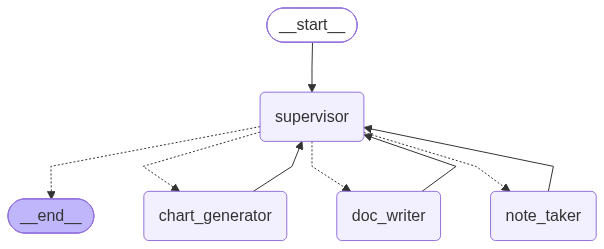

In [24]:
writing_team

We'll create a third graph to orchestrate the previous two, and add some connectors to define how this top-level state is shared between the different graphs.


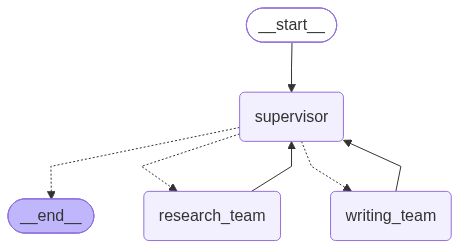

In [ ]:
# Create a supervisor workflow with the agents working beneth them

teams_supervisor  = create_supervisor(
    [research_team, writing_team],
    model = model,
    prompt=(
        "You are a team supervisor managing a research team and a paper writing team  "
    ),
)

super_agent = teams_supervisor.compile(name = 'super_agent')
super_agent


In [36]:
for s in super_agent.stream(
    {'messages': [HumanMessage('Write a poem about cats and then write it to disk.')]},
    {'recursion_limit': 100}
):
    print(s)

{'supervisor': None}
{'research_team': {'messages': [AIMessage(content='Here\'s a summary of what happened:\n\n- ✅ **Poem written** — A beautiful 5-stanza poem titled *"Whiskers in the Shadows"* was composed about cats.\n- ❌ **Writing to disk** — Unfortunately, neither my search expert nor my web scraper expert has the capability to write files to disk. That requires a code execution environment.\n\nTo save the poem yourself, simply copy the text and paste it into a text file, or use this quick Python snippet:\n\n```python\nwith open("cat_poem.txt", "w") as f:\n    f.write("Whiskers in the Shadows\\n\\n...")\n```\n\nWould you like anything else? 🐾', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '70f539ec-3c63-4fba-8b25-401e27e14046', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 19 Aug 2026 07:24:56 GMT', 'content-type': 'application/json', 'content-length': '919', 'connection': 'keep-alive', 'x-amzn-requestid': '70f539ec-3c63-4fba-8b25-401e27e14046'

We can create hierarchy of the super agents. Which calls each other as per the requirments.